# 01 — Preprocessing: dai file NASA al dataset dei cicli

Primo notebook della pipeline. Scarica il *NASA PCoE Battery Data Set* e costruisce il
dataset su cui lavorano tutti i notebook successivi.

Il percorso è: estrazione di un record aggregato per ciascun ciclo di scarica delle dieci
celle, definizione dello State of Health, individuazione dei cicli non rappresentativi,
estrazione degli indicatori di salute dai cicli di carica, e caratterizzazione delle
condizioni sperimentali di ciascuna cella.

**Output prodotti**

| percorso | contenuto |
|---|---|
| `data/processed/battery_cycles.csv` | un record per ciclo, con `soh`, `is_valid`, `segment_id` e gli indicatori di ricarica |
| `results/tables/protocolli_batterie.csv` | condizioni sperimentali di ciascuna cella |
| `results/tables/fade_rate_per_batteria.csv` | tasso di degrado per cella |
| `results/tables/segmenti_contigui.csv` | tratti di cicli consecutivi utilizzabili |
| `results/tables/indicatori_carica_correlazioni.csv` | coerenza fisica degli indicatori di ricarica |
| `results/figures/` | curve di capacità e SoH, profili di ricarica, tassi di degrado |

**Notebook successivo:** `02_sequence_preparation.ipynb`, che costruisce le finestre
temporali a partire da questo dataset.

I cicli non rappresentativi vengono marcati e non rimossi, e la numerazione originale è
conservata: la contiguità temporale resta così verificabile a valle, quando si
costruiscono le sequenze.


## 1. Configurazione del progetto


In [2]:
import glob
import os
import shutil
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io

# Su Google Colab il progetto risiede su Drive, che va montato prima di ogni accesso.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass


def find_project_root():
    """Individua la cartella di progetto, in locale o su Google Drive.

    Una directory è riconosciuta come radice se contiene sia `notebooks/` sia
    `data/`: richiederne una sola produrrebbe falsi positivi su qualunque cartella
    chiamata "data".
    """
    candidate_paths = []

    current_path = Path.cwd().resolve()
    candidate_paths.extend([current_path] + list(current_path.parents))
    candidate_paths.extend([
        Path("/content/drive/MyDrive/SoH_Neural_Tracker"),
        Path("/content/SoH_Neural_Tracker"),
    ])

    for path in candidate_paths:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path

    raise FileNotFoundError(
        "Cartella di progetto non trovata. Serve una directory SoH_Neural_Tracker "
        "contenente almeno notebooks/ e data/."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_ORIGINAL = PROJECT_ROOT / "data" / "original"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"

for folder in [DATA_ORIGINAL, DATA_PROCESSED, EXPERIMENTS_DIR,
               FIGURES_DIR, TABLES_DIR, PREDICTIONS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

SELECTED_BATTERIES = ["B0005", "B0006", "B0007", "B0018",
                      "B0029", "B0030", "B0031", "B0032",
                      "B0042", "B0043"]

print("Radice del progetto:", PROJECT_ROOT)
print(f"{len(SELECTED_BATTERIES)} celle selezionate:", ", ".join(SELECTED_BATTERIES))


Mounted at /content/drive
Radice del progetto: /content/drive/MyDrive/SoH_Neural_Tracker
10 celle selezionate: B0005, B0006, B0007, B0018, B0029, B0030, B0031, B0032, B0042, B0043


## 2. Download ed estrazione del dataset

L'archivio NASA contiene sette sottoarchivi. Ne servono due: `1. BatteryAgingARC-FY08Q4`
per B0005–B0018 e `3. BatteryAgingARC_25-44` per le restanti. Estrarre solo questi evita
di scompattare l'intero dataset.

Download ed estrazione vengono saltati se già eseguiti: l'archivio pesa alcune centinaia
di megabyte e ripetere l'operazione a ogni riesecuzione renderebbe il notebook
impraticabile.


In [3]:
NASA_ZIP_URL = "https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip"

ZIP_PATH = DATA_ORIGINAL / "nasa_battery_dataset.zip"
RAW_DIR = DATA_ORIGINAL / "nasa_battery_raw"
BATTERY_ROOT = RAW_DIR / "5. Battery Data Set"
SELECTED_DIR = DATA_ORIGINAL / "selected_batteries"
SELECTED_DIR.mkdir(parents=True, exist_ok=True)


def mat_disponibili():
    return sorted(glob.glob(str(SELECTED_DIR / "*.mat")))


# Il download serve solo se manca l'archivio estratto. La raccolta dei file .mat,
# invece, viene rifatta a ogni esecuzione: se si controllasse la sola presenza delle
# dieci celle del progetto, una cartella che le contiene già impedirebbe di
# raccogliere le altre, e l'esperimento supplementare resterebbe senza dati.
gia_presenti = {Path(f).stem for f in mat_disponibili()}
mancano_del_progetto = not set(SELECTED_BATTERIES) <= gia_presenti

# L'archivio contiene anche le celle che non fanno parte del progetto: servono
# all'esperimento supplementare sulla quantità di dati. Vale la pena scaricarlo anche
# quando le dieci celle principali ci sono già, se le altre non sono state raccolte.
solo_progetto = gia_presenti <= set(SELECTED_BATTERIES)
serve_download = (mancano_del_progetto or solo_progetto) and not BATTERY_ROOT.exists()

print("File .mat già raccolti:", len(mat_disponibili()))
print("Celle del progetto complete:", not mancano_del_progetto)
print("Archivio già estratto:      ", BATTERY_ROOT.exists())
print("Download necessario:        ", serve_download)


File .mat già raccolti: 0
Celle del progetto complete: False
Archivio già estratto:       False
Download necessario:         True


In [4]:
if serve_download:
    # Il download può fallire per motivi di rete. Se le celle del progetto sono già
    # presenti l'analisi principale prosegue comunque: a mancare sarà soltanto
    # l'esperimento supplementare, e il messaggio lo dice invece di interrompere tutto.
    try:
        if not ZIP_PATH.exists():
            print("Download del dataset NASA...")
            urllib.request.urlretrieve(NASA_ZIP_URL, ZIP_PATH)
        print("Archivio:", ZIP_PATH.name, f"({ZIP_PATH.stat().st_size / 1e6:.0f} MB)")

        print("Estrazione dell'archivio principale...")
        with zipfile.ZipFile(ZIP_PATH) as zip_ref:
            zip_ref.extractall(RAW_DIR)
    except Exception as errore:
        if mancano_del_progetto:
            raise
        print(f"Download non riuscito ({type(errore).__name__}): {errore}")
        print("Le celle del progetto sono già presenti, l'analisi principale prosegue.")
        print("L'esperimento supplementare sulla quantità di dati non sarà eseguibile.")

if BATTERY_ROOT.exists():
    for zip_name in ["1. BatteryAgingARC-FY08Q4.zip", "3. BatteryAgingARC_25-44.zip"]:
        archivio = BATTERY_ROOT / zip_name
        destinazione = BATTERY_ROOT / zip_name.replace(".zip", "")
        if archivio.exists() and not destinazione.exists():
            with zipfile.ZipFile(archivio) as zip_ref:
                zip_ref.extractall(destinazione)
            print("Estratto:", zip_name)

    # Tutte le celle disponibili negli archivi vengono raccolte. Le dieci del progetto
    # servono all'analisi principale; le altre alimentano l'esperimento supplementare
    # sulla quantità di dati di addestramento. La copia è idempotente.
    raccolte = 0
    for percorso in glob.glob(str(BATTERY_ROOT / "**" / "*.mat"), recursive=True):
        destinazione = SELECTED_DIR / os.path.basename(percorso)
        if not destinazione.exists():
            shutil.copy2(percorso, destinazione)
            raccolte += 1
    if raccolte:
        print(f"Nuovi file .mat raccolti: {raccolte}")

mat_files = mat_disponibili()
mat_progetto = [f for f in mat_files if Path(f).stem in SELECTED_BATTERIES]
mat_aggiuntive = [f for f in mat_files if Path(f).stem not in SELECTED_BATTERIES]

print(f"\n{len(mat_files)} file .mat in {SELECTED_DIR.relative_to(PROJECT_ROOT)}")
print(f"  {len(mat_progetto)} celle del progetto")
print(f"  {len(mat_aggiuntive)} celle aggiuntive")

mancanti = set(SELECTED_BATTERIES) - {Path(f).stem for f in mat_progetto}
assert not mancanti, f"celle del progetto non trovate negli archivi: {sorted(mancanti)}"


Download del dataset NASA...
Archivio: nasa_battery_dataset.zip (210 MB)
Estrazione dell'archivio principale...
Estratto: 1. BatteryAgingARC-FY08Q4.zip
Estratto: 3. BatteryAgingARC_25-44.zip
Nuovi file .mat raccolti: 22

22 file .mat in data/original/selected_batteries
  10 celle del progetto
  12 celle aggiuntive


## 3. Struttura dei file MATLAB

Ogni file contiene la sequenza completa dei cicli sperimentali di una cella, di tipo
`charge`, `discharge` e `impedance`. Solo i cicli di scarica riportano il campo
`Capacity`, ed è da quello che si ricava lo State of Health.

La cella seguente verifica il formato prima di scrivere l'estrattore, e quantifica quanta
parte del dataset viene effettivamente utilizzata.


In [5]:
def campo(valore):
    """Scende fino al contenuto di un campo MATLAB letto da scipy.

    A seconda della struttura del file, un campo può presentarsi come valore
    semplice, array 1x1 o array di oggetti annidati più volte. Rimuovere gli
    involucri rende la lettura indipendente da questa variabilità.
    """
    arr = np.asarray(valore)
    while arr.dtype == object and arr.size == 1:
        arr = np.asarray(arr.reshape(-1)[0])
    return arr


def tipo_ciclo(ciclo):
    """Restituisce il tipo di un ciclo: charge, discharge o impedance."""
    valori = campo(ciclo["type"]).reshape(-1)
    return str(valori[0]) if valori.size else ""


file_esempio = mat_progetto[0]
battery_id_esempio = Path(file_esempio).stem
cicli_esempio = scipy.io.loadmat(file_esempio)[battery_id_esempio][0, 0]["cycle"][0]

print("File di esempio:", Path(file_esempio).name)
print("Cicli totali nel file:", len(cicli_esempio))

tipi = pd.Series([tipo_ciclo(c) for c in cicli_esempio]).value_counts()
print("\nCicli per tipo:")
print(tipi.to_string())

for tipo in ["discharge", "charge"]:
    primo = next((c for c in cicli_esempio if tipo_ciclo(c) == tipo), None)
    if primo is not None:
        print(f"\nCampi disponibili in un ciclo di {tipo}:")
        print(np.asarray(primo["data"]).reshape(-1)[0].dtype.names)


File di esempio: B0005.mat
Cicli totali nel file: 616

Cicli per tipo:
impedance    278
charge       170
discharge    168

Campi disponibili in un ciclo di discharge:
('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')

Campi disponibili in un ciclo di charge:
('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time')


## 4. Estrazione dei cicli di scarica

Le serie temporali di tensione, corrente e temperatura vengono riassunte in media,
minimo, massimo e deviazione standard. La sintesi è voluta: i modelli lavorano su
sequenze di cicli e non sul profilo interno al singolo ciclo, e per una scarica a
corrente costante le statistiche di primo e secondo ordine ne descrivono la forma.


In [6]:
def safe_scalar(x):
    """Converte un campo MATLAB in scalare Python."""
    arr = campo(x).squeeze()
    return float(arr) if arr.size else np.nan


def safe_array(x):
    """Converte un campo MATLAB in array numpy monodimensionale."""
    return campo(x).squeeze().astype(float)


def extract_discharge_cycles(mat_file):
    """Estrae un record per ciclo di scarica da un file .mat del dataset NASA.

    Restituisce le righe estratte e l'elenco dei cicli scartati per errore di
    lettura, così che eventuali problemi risultino visibili invece di ridurre
    silenziosamente il dataset.
    """
    battery_id = Path(mat_file).stem
    cycles = scipy.io.loadmat(mat_file)[battery_id][0, 0]["cycle"][0]

    rows, scartati = [], []

    for raw_cycle_index, cycle in enumerate(cycles):
        if tipo_ciclo(cycle) != "discharge":
            continue

        data = np.asarray(cycle["data"]).reshape(-1)[0]
        if data.dtype.names is None or "Capacity" not in data.dtype.names:
            continue

        try:
            voltage = safe_array(data["Voltage_measured"])
            current = safe_array(data["Current_measured"])
            temperature = safe_array(data["Temperature_measured"])
            time = safe_array(data["Time"])

            rows.append({
                "battery_id": battery_id,
                # Posizione nel file sorgente: permette di risalire al ciclo
                # originale e di contare i cicli di carica e impedenza interposti.
                "raw_cycle_index": raw_cycle_index,
                "discharge_cycle": len(rows),
                "ambient_temperature": safe_scalar(cycle["ambient_temperature"]),
                "capacity": safe_scalar(data["Capacity"]),

                "voltage_mean": np.mean(voltage),
                "voltage_min": np.min(voltage),
                "voltage_max": np.max(voltage),
                "voltage_std": np.std(voltage),

                "current_mean": np.mean(current),
                "current_min": np.min(current),
                "current_max": np.max(current),
                "current_std": np.std(current),

                "temperature_mean": np.mean(temperature),
                "temperature_min": np.min(temperature),
                "temperature_max": np.max(temperature),
                "temperature_std": np.std(temperature),

                "discharge_time": time[-1] - time[0] if len(time) > 1 else np.nan,
                "num_measurements": len(time),
            })

        except Exception as errore:
            scartati.append((battery_id, raw_cycle_index, str(errore)))

    return rows, scartati


In [7]:
tutte_le_righe, tutti_gli_scartati = [], []

for mat_file in mat_progetto:
    righe, scartati = extract_discharge_cycles(mat_file)
    tutte_le_righe.extend(righe)
    tutti_gli_scartati.extend(scartati)

df_cycles = pd.DataFrame(tutte_le_righe)

print("Cicli di scarica estratti:", len(df_cycles))
print("Cicli scartati per errore di lettura:", len(tutti_gli_scartati))
if tutti_gli_scartati:
    display(pd.DataFrame(tutti_gli_scartati, columns=["battery_id", "ciclo", "errore"]))

display(df_cycles.groupby("battery_id").size().rename("n_cicli").to_frame().T)
display(df_cycles.head(5))


Cicli di scarica estratti: 1020
Cicli scartati per errore di lettura: 0


battery_id,B0005,B0006,B0007,B0018,B0029,B0030,B0031,B0032,B0042,B0043
n_cicli,168,168,168,132,40,40,40,40,112,112


,battery_id,raw_cycle_index,discharge_cycle,ambient_temperature,capacity,voltage_mean,voltage_min,voltage_max,voltage_std,current_mean,current_min,current_max,current_std,temperature_mean,temperature_min,temperature_max,temperature_std,discharge_time,num_measurements
0,B0005,1,0,24.0,1.856487,3.529829,2.612467,4.191492,0.235957,-1.818702,-2.018015,0.000729,0.593546,32.572328,24.325993,38.982181,3.486920,3690.234,197
1,B0005,3,1,24.0,1.846327,3.537320,2.587209,4.189773,0.234765,-1.817560,-2.016821,0.002927,0.595180,32.725235,24.685948,39.033398,3.426734,3672.344,196
2,B0005,5,2,24.0,1.835349,3.543737,2.651917,4.188187,0.227525,-1.816487,-2.016574,0.001484,0.596498,32.642862,24.734266,38.818797,3.379475,3651.641,195
3,B0005,7,3,24.0,1.835263,3.543666,2.592948,4.188461,0.232744,-1.825589,-2.015936,0.001547,0.583462,32.514876,24.652244,38.762305,3.386544,3631.563,194
4,B0005,9,4,24.0,1.834646,3.542343,2.547420,4.188299,0.236689,-1.826114,-2.017426,0.001701,0.583469,32.382349,24.518700,38.665393,3.395881,3629.172,194


## 5. Definizione dello State of Health

$$\mathrm{SoH}(t) = \frac{C(t)}{C_{\text{rif}}}$$

La scelta di $C_{\text{rif}}$ determina cosa il valore misura e quali informazioni
presuppone. Si adotta la **mediana dei primi cinque cicli** di ciascuna cella: è un
riferimento stimato da misure che precedono qualunque istante di predizione, condizione
necessaria perché il target resti calcolabile anche su una batteria in servizio. La
mediana, anziché la prima misura singola, evita che il rumore di un solo ciclo iniziale
si propaghi all'intera serie.

Un riferimento alternativo è il massimo osservato sull'intera traiettoria: produce per
costruzione $\max(\mathrm{SoH}) = 1$, ma richiede di conoscere la vita completa della
cella e non è quindi calcolabile in esercizio. La cella seguente calcola entrambi e ne
riporta lo scarto, per documentare l'entità della differenza.


In [8]:
N_CICLI_RIFERIMENTO = 5

df_cycles = df_cycles.sort_values(["battery_id", "discharge_cycle"]).reset_index(drop=True)

df_cycles["capacity_reference"] = (
    df_cycles.groupby("battery_id")["capacity"]
    .transform(lambda s: s.iloc[:N_CICLI_RIFERIMENTO].median())
)
df_cycles["soh"] = df_cycles["capacity"] / df_cycles["capacity_reference"]

# Riferimento alternativo, calcolato solo per documentarne lo scarto.
riferimento_massimo = df_cycles.groupby("battery_id")["capacity"].transform("max")

confronto_riferimenti = pd.DataFrame({
    "battery_id": df_cycles["battery_id"],
    "primi_cicli": df_cycles["capacity_reference"],
    "massimo_globale": riferimento_massimo,
}).drop_duplicates().reset_index(drop=True)
confronto_riferimenti["scarto_pct"] = 100 * (
    confronto_riferimenti.massimo_globale / confronto_riferimenti.primi_cicli - 1
)

main_columns = [
    "battery_id", "raw_cycle_index", "discharge_cycle", "ambient_temperature",
    "capacity", "capacity_reference", "soh",
    "voltage_mean", "voltage_min", "voltage_max", "voltage_std",
    "current_mean", "current_min", "current_max", "current_std",
    "temperature_mean", "temperature_min", "temperature_max", "temperature_std",
    "discharge_time", "num_measurements",
]
df_cycles = df_cycles[main_columns]

print("Confronto fra i due riferimenti di capacità:")
display(confronto_riferimenti.round(4))

print(f"SoH: min {df_cycles.soh.min():.4f}   max {df_cycles.soh.max():.4f}")
print("Cicli con SoH > 1:", int((df_cycles.soh > 1).sum()))


Confronto fra i due riferimenti di capacità:


,battery_id,primi_cicli,massimo_globale,scarto_pct
0,B0005,1.8353,1.8565,1.1517
1,B0006,2.0133,2.0353,1.0933
2,B0007,1.8807,1.8911,0.5524
3,B0018,1.8396,1.8550,0.8373
4,B0029,1.8158,1.8447,1.5944
5,B0030,1.7518,1.7816,1.7011
6,B0031,1.8044,1.8329,1.5750
7,B0032,1.8655,1.8940,1.5297
8,B0042,1.7282,1.7315,0.1872
9,B0043,1.6815,1.7138,1.9204


SoH: min 0.0000   max 1.0192
Cicli con SoH > 1: 33


Alcuni cicli presentano SoH superiore a 1. Non è un errore di calcolo: le celle agli ioni
di litio recuperano capacità apparente dopo i periodi di riposo, e con questo riferimento
il fenomeno resta visibile anziché essere assorbito dalla normalizzazione. La
rigenerazione è una delle ragioni per cui il degrado non è monotono, e va tenuta presente
nell'interpretazione dei risultati.


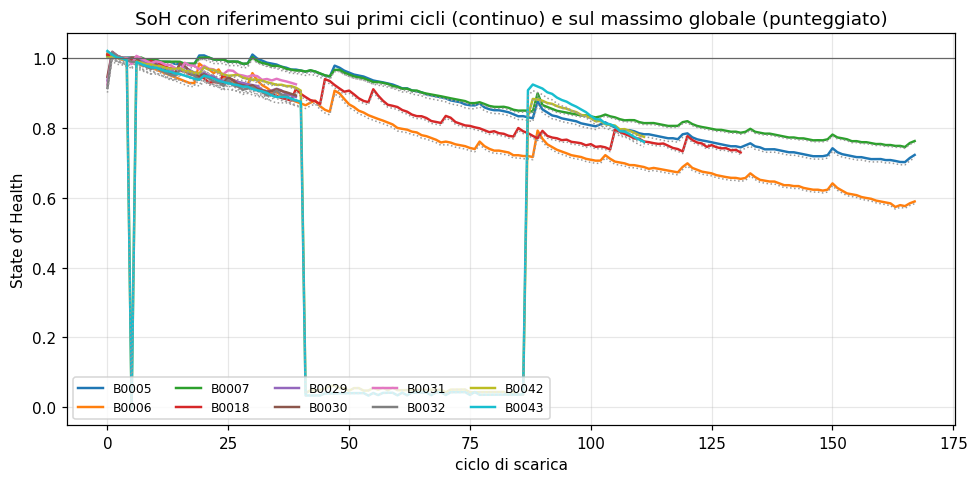

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for battery_id, gruppo in df_cycles.groupby("battery_id"):
    ax.plot(gruppo.discharge_cycle, gruppo.soh, lw=1.6, label=battery_id)
    soh_massimo = gruppo.capacity / gruppo.capacity.max()
    ax.plot(gruppo.discharge_cycle, soh_massimo, lw=1.0, ls=":", color="0.6")

ax.axhline(1.0, lw=0.8, color="0.4")
ax.set_xlabel("ciclo di scarica")
ax.set_ylabel("State of Health")
ax.set_title("SoH con riferimento sui primi cicli (continuo) e sul massimo globale (punteggiato)")
ax.legend(ncol=5, fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_confronto_definizioni_soh.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Cicli non rappresentativi

Il dataset contiene cicli in cui la capacità misurata crolla e nei cicli successivi torna
ai valori attesi. Un decadimento fisico non si inverte: si tratta di scariche parziali o
test interrotti, non confrontabili con i cicli di capacità nominali.

Il criterio è **locale**: un ciclo è marcato se la sua capacità scende sotto metà della
mediana dei cicli circostanti. Il confronto con il vicinato isola i crolli isolati
indipendentemente da quanto la cella sia già degradata. Una soglia assoluta sul SoH
marcherebbe invece anche le batterie legittimamente prossime a fine vita, i cui cicli
sono validi e anzi particolarmente informativi.


In [10]:
FINESTRA_LOCALE = 11
RAPPORTO_CROLLO = 0.5
SOGLIA_ASSOLUTA = 0.3

df_cycles = df_cycles.sort_values(["battery_id", "discharge_cycle"]).reset_index(drop=True)

df_cycles["capacity_local_median"] = (
    df_cycles.groupby("battery_id")["capacity"]
    .transform(lambda s: s.rolling(FINESTRA_LOCALE, center=True, min_periods=3).median())
)

df_cycles["is_local_outlier"] = (
    df_cycles["capacity"] < RAPPORTO_CROLLO * df_cycles["capacity_local_median"]
)
# Garanzia secondaria sui cicli a capacità praticamente nulla.
df_cycles["is_below_floor"] = df_cycles["soh"] < SOGLIA_ASSOLUTA
df_cycles["is_anomalous"] = df_cycles["is_local_outlier"] | df_cycles["is_below_floor"]
df_cycles["is_valid"] = ~df_cycles["is_anomalous"]

cicli_marcati = df_cycles[df_cycles["is_anomalous"]]
print(f"Cicli marcati: {len(cicli_marcati)} su {len(df_cycles)}")

display(cicli_marcati[[
    "battery_id", "discharge_cycle", "capacity", "capacity_local_median",
    "soh", "ambient_temperature", "discharge_time", "num_measurements",
]].round(4))


Cicli marcati: 94 su 1020


,battery_id,discharge_cycle,capacity,capacity_local_median,soh,ambient_temperature,discharge_time,num_measurements
801,B0042,5,0.0000,1.7087,0.0000,22.0,2646.625,274
837,B0042,41,0.0707,0.1060,0.0409,4.0,1055.250,91
838,B0042,42,0.0842,0.1060,0.0487,4.0,1012.187,87
839,B0042,43,0.0844,0.0944,0.0489,4.0,991.172,85
840,B0042,44,0.0848,0.0944,0.0491,4.0,982.094,84
...,...,...,...,...,...,...,...,...
990,B0043,82,0.0613,0.0612,0.0365,4.0,109.171,10
991,B0043,83,0.0613,0.0613,0.0365,4.0,96.484,9
992,B0043,84,0.0612,0.0613,0.0364,4.0,109.094,10
993,B0043,85,0.0614,0.0614,0.0365,4.0,96.906,9


## 7. Blocchi di protocollo e tratti contigui

Prima di costruire qualunque sequenza vanno individuate le due discontinuità che una
finestra temporale non deve attraversare.

**La prima è il cambio di protocollo.** Non tutte le celle sono state ciclate a
condizioni costanti: alcune cambiano temperatura ambiente e corrente di scarica a metà
della propria vita. Una finestra a cavallo del cambio conterrebbe cicli misurati in due
regimi diversi e descriverebbe una transizione sperimentale, non un'evoluzione dello
stato di salute. Ogni cella viene quindi divisa in **blocchi di protocollo**: tratti
consecutivi di cicli con la stessa temperatura ambiente. Il blocco, e non la cella,
diventa l'unità con cui si formano gli insiemi nel notebook successivo.

**La seconda è il ciclo scartato.** Perché una finestra rappresenti un'evoluzione
realmente osservata, i suoi cicli devono essere validi e adiacenti nella numerazione
originale; un ciclo marcato interrompe il tratto.

La colonna `segment_id` numera i tratti dentro ciascun blocco di protocollo. Ai cicli
marcati viene assegnato `segment_id = -1`, così che restino nel dataset ma non possano
essere raggruppati con quelli validi.


In [11]:
def assegna_blocchi_protocollo(df):
    """Divide ogni cella in tratti consecutivi con la stessa temperatura ambiente.

    L'identificativo risultante ha forma `B0042_p1`, `B0042_p2`: una cella ciclata a
    condizioni costanti produce un solo blocco e l'identificativo è equivalente al suo
    nome, quindi la divisione non ha effetto dove non serve.
    """
    df = df.sort_values(["battery_id", "discharge_cycle"]).copy()
    etichette = []

    for battery_id, gruppo in df.groupby("battery_id", sort=False):
        ambiente = gruppo["ambient_temperature"].to_numpy()
        apre = np.ones(len(gruppo), dtype=bool)
        apre[1:] = ambiente[1:] != ambiente[:-1]
        numero = np.cumsum(apre)
        etichette.extend(f"{battery_id}_p{n}" for n in numero)

    df["protocol_block"] = etichette
    return df


def assegna_segmenti(df):
    """Numera i tratti massimali di cicli validi e consecutivi dentro ogni blocco."""
    df = df.sort_values(["battery_id", "discharge_cycle"]).copy()
    identificativi = np.empty(len(df), dtype=int)

    posizione = 0
    for _, gruppo in df.groupby("protocol_block", sort=False):
        cicli = gruppo["discharge_cycle"].to_numpy()
        validi = gruppo["is_valid"].to_numpy()

        # Un nuovo tratto inizia dove cambia la validità o dove la numerazione salta.
        inizi = np.ones(len(gruppo), dtype=bool)
        inizi[1:] = (validi[1:] != validi[:-1]) | (np.diff(cicli) != 1)
        ids = np.cumsum(inizi) - 1
        ids[~validi] = -1

        identificativi[posizione:posizione + len(gruppo)] = ids
        posizione += len(gruppo)

    df["segment_id"] = identificativi
    return df


df_cycles = assegna_segmenti(assegna_blocchi_protocollo(df_cycles))

riepilogo_segmenti = []
for blocco, gruppo in df_cycles.groupby("protocol_block"):
    validi = gruppo[gruppo.segment_id >= 0]
    lunghezze = validi.groupby("segment_id").size()
    riepilogo_segmenti.append({
        "protocol_block": blocco,
        "battery_id": gruppo.battery_id.iloc[0],
        "ambiente_c": float(gruppo.ambient_temperature.iloc[0]),
        "corrente_a": round(float(gruppo.current_mean.abs().median()), 2),
        "n_cicli": len(gruppo),
        "n_validi": int(gruppo.is_valid.sum()),
        "n_marcati": int(gruppo.is_anomalous.sum()),
        "n_segmenti": int(lunghezze.size),
        "segmento_piu_lungo": int(lunghezze.max()) if lunghezze.size else 0,
    })

riepilogo_segmenti = (pd.DataFrame(riepilogo_segmenti)
                      .sort_values("protocol_block").reset_index(drop=True))
display(riepilogo_segmenti)

divise = df_cycles.groupby("battery_id").protocol_block.nunique()
divise = divise[divise > 1]
if len(divise):
    print("Celle a protocollo non costante, divise in blocchi:")
    for battery_id, n in divise.items():
        blocchi = df_cycles[df_cycles.battery_id == battery_id]
        for blocco, gruppo in blocchi.groupby("protocol_block"):
            print(f"  {blocco}: {len(gruppo):3d} cicli a "
                  f"{gruppo.ambient_temperature.iloc[0]:.0f} °C, "
                  f"{gruppo.current_mean.abs().median():.1f} A, "
                  f"durata media {gruppo.discharge_time.mean():.0f} s")
else:
    print("Tutte le celle hanno protocollo costante.")

frammentate = riepilogo_segmenti[riepilogo_segmenti.n_segmenti > 1]
if len(frammentate):
    print("\nBlocchi articolati in più tratti:", ", ".join(frammentate.protocol_block))
    print("Le finestre temporali verranno costruite dentro ciascun tratto.")


,protocol_block,battery_id,ambiente_c,corrente_a,n_cicli,n_validi,n_marcati,n_segmenti,segmento_piu_lungo
0,B0005_p1,B0005,24.0,1.82,168,168,0,1,168
1,B0006_p1,B0006,24.0,1.75,168,168,0,1,168
2,B0007_p1,B0007,24.0,1.90,168,168,0,1,168
3,B0018_p1,B0018,24.0,1.82,132,132,0,1,132
4,B0029_p1,B0029,43.0,3.92,40,40,0,1,40
5,B0030_p1,B0030,43.0,3.77,40,40,0,1,40
6,B0031_p1,B0031,43.0,3.92,40,40,0,1,40
7,B0032_p1,B0032,43.0,3.89,40,40,0,1,40
8,B0042_p1,B0042,22.0,2.00,41,40,1,2,35
9,B0042_p2,B0042,4.0,3.87,71,25,46,1,25


Celle a protocollo non costante, divise in blocchi:
  B0042_p1:  41 cicli a 22 °C, 2.0 A, durata media 3019 s
  B0042_p2:  71 cicli a 4 °C, 3.9 A, durata media 2436 s
  B0043_p1:  41 cicli a 22 °C, 1.9 A, durata media 3019 s
  B0043_p2:  71 cicli a 4 °C, 0.5 A, durata media 2436 s

Blocchi articolati in più tratti: B0042_p1, B0043_p1
Le finestre temporali verranno costruite dentro ciascun tratto.


### Verifica delle proprietà del dataset

Le due condizioni su cui poggiano i risultati a valle vengono controllate esplicitamente.
Sono violazioni che producono comunque numeri plausibili, e che un'ispezione visiva dei
grafici non intercetta.


In [12]:
# Ogni tratto deve contenere cicli consecutivi e tutti validi.
for (blocco, segmento), gruppo in (
    df_cycles[df_cycles.segment_id >= 0].groupby(["protocol_block", "segment_id"])
):
    cicli = gruppo["discharge_cycle"].to_numpy()
    assert np.all(np.diff(cicli) == 1), f"{blocco} segmento {segmento}: numerazione con salti"
    assert gruppo["is_valid"].all(), f"{blocco} segmento {segmento}: contiene cicli marcati"
    assert gruppo["ambient_temperature"].nunique() == 1, f"{blocco}: temperatura ambiente non costante"

# Il riferimento di capacità non deve dipendere da cicli futuri: troncando la serie,
# il SoH già assegnato ai cicli precedenti deve restare invariato.
troncato = df_cycles[df_cycles.discharge_cycle < 30].copy()
riferimento_troncato = (
    troncato.groupby("battery_id")["capacity"]
    .transform(lambda s: s.iloc[:N_CICLI_RIFERIMENTO].median())
)
assert np.allclose(troncato["soh"], troncato["capacity"] / riferimento_troncato), (
    "il SoH cambia se la serie viene troncata: il riferimento usa informazione futura"
)

print("Verifiche superate:")
print("  - tutti i tratti contengono cicli consecutivi, validi e a protocollo costante")
print("  - il SoH non dipende da cicli successivi a quello considerato")


Verifiche superate:
  - tutti i tratti contengono cicli consecutivi, validi e a protocollo costante
  - il SoH non dipende da cicli successivi a quello considerato


## 8. Il protocollo di carica

Le celle del dataset seguono un protocollo a **corrente costante seguita da tensione
costante**. Nella prima fase la corrente resta al valore di setpoint e la tensione sale;
raggiunti i 4.2 V la tensione viene mantenuta e la corrente decade fino alla soglia di
fine carica.

Le due fasi invecchiano in modo opposto e complementare. Una cella degradata accumula
meno carica, quindi attraversa la finestra di tensione della fase a corrente costante in
**meno tempo**; al contempo la sua resistenza interna cresce, e la coda a tensione
costante si **allunga**. La cella seguente mostra il profilo di una ricarica per rendere
leggibili le grandezze che verranno estratte.


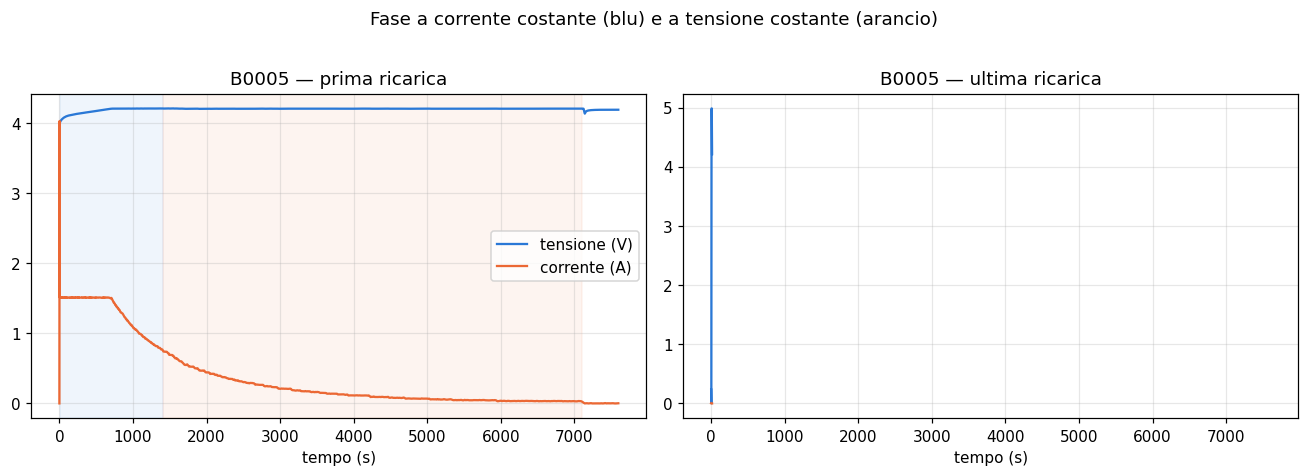

In [13]:
CORRENTE_CC = 1.5        # A, setpoint della fase a corrente costante
TENSIONE_CV = 4.2        # V, tensione della fase a tensione costante
CORRENTE_FINE = 0.02     # A, soglia di fine carica
FINESTRA_CC = (3.8, 4.1) # V, intervallo su cui misurare il tempo di carica


def serie(dato, nome):
    return campo(dato[nome]).squeeze().astype(float)


def fasi_carica(tensione, corrente):
    """Separa la fase a corrente costante da quella a tensione costante.

    La discriminante è la corrente: resta al setpoint durante la prima fase e decade
    nella seconda. La soglia a metà del setpoint è insensibile al rumore di misura e
    non richiede di conoscere in anticipo il punto di transizione in tensione.
    """
    cc = corrente > 0.5 * CORRENTE_CC
    cv = (~cc) & (corrente > CORRENTE_FINE) & (tensione > 0.95 * TENSIONE_CV)
    return cc, cv


# Profilo di una ricarica, all'inizio e alla fine della vita di una cella.
esempio = scipy.io.loadmat(mat_files[0])[Path(mat_files[0]).stem][0, 0]["cycle"][0]
cariche = [c for c in esempio if tipo_ciclo(c) == "charge"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for ax, ciclo, titolo in [(axes[0], cariche[0], "prima ricarica"),
                          (axes[1], cariche[-1], "ultima ricarica")]:
    dato = np.asarray(ciclo["data"]).reshape(-1)[0]
    tempo = serie(dato, "Time")
    tensione = serie(dato, "Voltage_measured")
    corrente = np.abs(serie(dato, "Current_measured"))
    cc, cv = fasi_carica(tensione, corrente)

    ax.plot(tempo, tensione, color="#2a78d6", label="tensione (V)")
    ax.plot(tempo, corrente, color="#eb6834", label="corrente (A)")
    if cc.any():
        ax.axvspan(tempo[cc][0], tempo[cc][-1], color="#2a78d6", alpha=0.07)
    if cv.any():
        ax.axvspan(tempo[cv][0], tempo[cv][-1], color="#eb6834", alpha=0.07)
    ax.set_title(f"{Path(mat_files[0]).stem} — {titolo}")
    ax.set_xlabel("tempo (s)")

axes[0].legend(loc="center right")
fig.suptitle("Fase a corrente costante (blu) e a tensione costante (arancio)", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01b_profilo_carica.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Indicatori di salute dalla ricarica

| indicatore | andamento con l'invecchiamento | interpretazione |
|---|---|---|
| `cc_time_3v8_4v1_s` | diminuisce | tempo per attraversare una finestra di tensione fissa a corrente costante: proporzionale alla carica accumulata in quella finestra |
| `charge_cc_ah` | diminuisce | carica accumulata nella sola fase a corrente costante |
| `cv_time_fraction` | aumenta | quota di ricarica spesa nella coda a tensione costante, che si allunga al crescere della resistenza interna |
| `ica_peak_height` | diminuisce | altezza del picco della curva dQ/dV: riflette la perdita di materiale attivo e di litio ciclabile |
| `ica_peak_voltage` | si sposta | posizione del picco lungo l'asse di tensione |
| `charge_temp_rise` | aumenta | riscaldamento per effetto Joule su una resistenza crescente |
| `charge_throughput_ah` | ambiguo | carica totale accettata: include la coda a tensione costante, che si allunga mentre la capacità cala, quindi i due effetti si compensano in parte |

L'ultimo indicatore è riportato per completezza ma è il meno affidabile dei sette: la
sezione 5 ne verifica il comportamento sui dati.


In [14]:
def tempo_carica_cc(tensione, tempo, cc, v_bassa, v_alta):
    """Tempo impiegato in fase CC per passare da `v_bassa` a `v_alta`.

    Se la cella non attraversa l'intera finestra, l'indicatore non è definito e viene
    restituito NaN: estrapolare produrrebbe un valore che si propagherebbe
    silenziosamente fino alle metriche finali.
    """
    v, t = tensione[cc], tempo[cc]
    if v.size < 2 or v.min() > v_bassa or v.max() < v_alta:
        return np.nan
    ordine = np.argsort(v)   # in fase CC la tensione è crescente
    return float(np.interp(v_alta, v[ordine], t[ordine])
                 - np.interp(v_bassa, v[ordine], t[ordine]))


def picco_capacita_incrementale(tensione, corrente, tempo, cc,
                                n_bin=60, intervallo=(3.6, 4.2)):
    """Altezza e posizione del picco della curva dQ/dV in fase CC.

    La curva si ottiene per binning in tensione anziché per derivazione puntuale:
    su dati campionati a passo irregolare la derivata diretta è dominata dal rumore.
    """
    v, i, t = tensione[cc], corrente[cc], tempo[cc]
    if v.size < 10:
        return np.nan, np.nan

    carica = np.concatenate([[0.0], np.cumsum(i[1:] * np.diff(t))]) / 3600.0
    bordi = np.linspace(*intervallo, n_bin + 1)
    carica_ai_bordi = np.interp(bordi, v, carica, left=np.nan, right=np.nan)

    ica = np.diff(carica_ai_bordi) / np.diff(bordi)
    if np.all(np.isnan(ica)):
        return np.nan, np.nan

    centri = 0.5 * (bordi[:-1] + bordi[1:])
    k = int(np.nanargmax(ica))
    return float(ica[k]), float(centri[k])


def indicatori_carica(dato, ambiente):
    """Indicatori di salute estratti da un singolo ciclo di carica."""
    tensione = serie(dato, "Voltage_measured")
    # Il segno della corrente misurata varia per convenzione: interessa il modulo.
    corrente = np.abs(serie(dato, "Current_measured"))
    temperatura = serie(dato, "Temperature_measured")
    tempo = serie(dato, "Time")

    cc, cv = fasi_carica(tensione, corrente)

    def durata(maschera):
        return float(tempo[maschera][-1] - tempo[maschera][0]) if maschera.sum() > 1 else np.nan

    durata_cc, durata_cv = durata(cc), durata(cv)
    durata_totale = float(tempo[-1] - tempo[0]) if tempo.size > 1 else np.nan

    altezza_ica, tensione_ica = picco_capacita_incrementale(tensione, corrente, tempo, cc)

    return {
        "cc_duration_s": durata_cc,
        "cv_duration_s": durata_cv,
        "charge_duration_s": durata_totale,
        "cv_time_fraction": durata_cv / durata_totale if durata_totale else np.nan,
        "charge_throughput_ah": float(np.trapezoid(corrente, tempo) / 3600.0)
                                if tempo.size > 1 else np.nan,
        "charge_cc_ah": float(np.trapezoid(corrente[cc], tempo[cc]) / 3600.0)
                        if cc.sum() > 1 else np.nan,
        "cc_time_3v8_4v1_s": tempo_carica_cc(tensione, tempo, cc, *FINESTRA_CC),
        "charge_temp_max": float(temperatura.max()) if temperatura.size else np.nan,
        "charge_temp_rise": float(temperatura.max() - temperatura[0])
                            if temperatura.size else np.nan,
        "ica_peak_height": altezza_ica,
        "ica_peak_voltage": tensione_ica,
        "charge_ambient_temperature": ambiente,
    }


INDICATORI = ["cc_time_3v8_4v1_s", "charge_cc_ah", "cv_time_fraction",
              "ica_peak_height", "ica_peak_voltage", "charge_temp_rise",
              "charge_throughput_ah", "cv_duration_s", "charge_duration_s",
              "cc_duration_s", "charge_temp_max"]
print(f"{len(INDICATORI)} indicatori definiti")


11 indicatori definiti


## 10. Accoppiamento carica → scarica

Il protocollo alterna carica e scarica, quindi la scarica che segue una ricarica è la
prima misura di capacità disponibile dopo di essa. La direzione è quella corretta: si
osserva la ricarica e si stima la capacità che verrà misurata **dopo**, non viceversa.

Viene registrato anche `cicli_interposti`, il numero di cicli di altro tipo — tipicamente
misure di impedenza — che separano la carica dalla scarica. Un intervallo lungo indica un
riposo prolungato, durante il quale la cella recupera capacità apparente: è una delle
cause dei rialzi visibili nelle curve di SoH.


In [15]:
def estrai_coppie_carica_scarica(mat_file):
    """Associa ogni ciclo di carica alla scarica immediatamente successiva."""
    battery_id = Path(mat_file).stem
    cicli = scipy.io.loadmat(mat_file)[battery_id][0, 0]["cycle"][0]

    righe = []
    in_attesa = None
    interposti = 0

    for indice, ciclo in enumerate(cicli):
        tipo = tipo_ciclo(ciclo)
        dato = np.asarray(ciclo["data"]).reshape(-1)[0]
        ambiente = float(campo(ciclo["ambient_temperature"]).squeeze())

        if tipo == "charge":
            in_attesa = {"battery_id": battery_id,
                         "charge_raw_index": indice,
                         **indicatori_carica(dato, ambiente)}
            interposti = 0

        elif tipo == "discharge" and in_attesa is not None:
            if dato.dtype.names is None or "Capacity" not in dato.dtype.names:
                continue
            in_attesa["discharge_raw_index"] = indice
            in_attesa["cicli_interposti"] = interposti
            righe.append(in_attesa)
            in_attesa = None

        else:
            interposti += 1

    df = pd.DataFrame(righe)
    if not df.empty:
        # Progressivo di scarica, per allinearsi al dataset del preprocessing.
        df["discharge_cycle"] = np.arange(len(df))
    return df


df_carica = pd.concat([estrai_coppie_carica_scarica(f) for f in mat_files],
                      ignore_index=True)

print("Coppie carica-scarica estratte:", len(df_carica))
display(df_carica.groupby("battery_id").size().rename("n_coppie").to_frame().T)

mancanti = df_carica[INDICATORI].isna().mean().sort_values(ascending=False) * 100
print("\nPercentuale di valori non definiti per indicatore:")
print(mancanti.round(1).to_string())


Coppie carica-scarica estratte: 2029


battery_id,B0005,B0006,B0007,B0018,B0025,B0026,B0027,B0028,B0029,B0030,B0031,B0032,B0033,B0034,B0036,B0038,B0039,B0040,B0041,B0042,B0043,B0044
n_coppie,167,167,167,132,28,28,28,28,39,39,39,39,196,196,196,46,46,46,66,112,112,112



Percentuale di valori non definiti per indicatore:
cc_time_3v8_4v1_s       11.8
ica_peak_voltage         7.3
ica_peak_height          7.3
charge_temp_max          0.4
charge_throughput_ah     0.4
charge_temp_rise         0.4
cv_time_fraction         0.0
cv_duration_s            0.0
charge_cc_ah             0.0
charge_duration_s        0.0
cc_duration_s            0.0


In [16]:
n_prima = len(df_cycles)
df_cycles = df_cycles.merge(
    df_carica.drop(columns=["charge_raw_index", "discharge_raw_index"]),
    on=["battery_id", "discharge_cycle"], how="left",
)
assert len(df_cycles) == n_prima, "l'unione ha alterato il numero di righe"

senza_carica = df_cycles[INDICATORI].isna().all(axis=1).sum()
print(f"Cicli di scarica: {len(df_cycles)}")
print(f"Senza ricarica associata: {senza_carica}")
display(df_cycles[["battery_id", "discharge_cycle", "soh", "cc_time_3v8_4v1_s",
            "cv_time_fraction", "charge_cc_ah", "cicli_interposti"]].head(5).round(4))


Cicli di scarica: 1020
Senza ricarica associata: 7


,battery_id,discharge_cycle,soh,cc_time_3v8_4v1_s,cv_time_fraction,charge_cc_ah,cicli_interposti
0,B0005,0,1.0115,96.6589,0.7495,0.5037,0.0
1,B0005,1,1.0060,2348.4701,0.5792,1.5940,0.0
2,B0005,2,1.0000,2363.6692,0.5647,1.5894,0.0
3,B0005,3,1.0000,2366.2855,0.5681,1.5837,0.0
4,B0005,4,0.9996,2369.6496,0.5477,1.5837,0.0


## 11. Verifica di coerenza fisica

Prima di usarli come variabili di ingresso, gli indicatori vengono confrontati con il SoH
misurato. La correlazione è calcolata **entro ciascuna cella**: fra celle diverse
intervengono capacità nominali e protocolli differenti, e una correlazione calcolata sul
pool confonderebbe la relazione cercata con le differenze fra unità sperimentali.

Il segno atteso è positivo per gli indicatori che diminuiscono con il degrado
(`cc_time_3v8_4v1_s`, `charge_cc_ah`) e negativo per quelli che crescono
(`cv_time_fraction`, `cv_duration_s`). Per il picco di dQ/dV la direzione dipende da
quale picco viene intercettato dal massimo, dato che l'invecchiamento ne modifica sia
l'altezza sia la posizione: l'indicatore viene quindi valutato empiricamente.

Il criterio di ammissione è la **coerenza del segno fra tutte le celle**: un indicatore
la cui relazione con il SoH cambia direzione da una cella all'altra non descrive il
degrado ma qualcosa di specifico della singola unità, e non è utilizzabile.


In [17]:
correlazioni = []
for battery_id, gruppo in df_cycles[df_cycles.is_valid].groupby("battery_id"):
    for indicatore in INDICATORI:
        valido = gruppo[[indicatore, "soh"]].dropna()
        if len(valido) < 10 or valido[indicatore].nunique() < 3:
            continue
        correlazioni.append({
            "battery_id": battery_id,
            "indicatore": indicatore,
            "correlazione_con_soh": valido[indicatore].corr(valido["soh"]),
            "n": len(valido),
        })

correlazioni = pd.DataFrame(correlazioni)

riepilogo = (correlazioni.groupby("indicatore")
             .agg(celle=("battery_id", "count"),
                  correlazione_media=("correlazione_con_soh", "mean"),
                  minima=("correlazione_con_soh", "min"),
                  massima=("correlazione_con_soh", "max"))
             .sort_values("correlazione_media", key=abs, ascending=False)
             .round(3).reset_index())
display(riepilogo)

# Un indicatore è utilizzabile se il segno della relazione è lo stesso in tutte le celle.
riepilogo["segno_coerente"] = np.sign(riepilogo.minima) == np.sign(riepilogo.massima)
coerenti = riepilogo[riepilogo.segno_coerente].indicatore.tolist()
print("Indicatori con segno coerente in tutte le celle:")
for nome in coerenti:
    print("  ", nome)


,indicatore,celle,correlazione_media,minima,massima
0,cc_time_3v8_4v1_s,10,0.822,0.561,0.939
1,charge_cc_ah,10,0.770,0.525,0.930
2,cc_duration_s,10,0.734,0.382,0.929
3,charge_throughput_ah,10,0.662,0.205,0.928
4,ica_peak_voltage,8,-0.639,-0.845,-0.235
5,cv_time_fraction,10,-0.628,-0.850,0.599
6,ica_peak_height,10,0.499,-0.391,0.990
7,cv_duration_s,10,-0.431,-0.876,0.680
8,charge_duration_s,10,0.183,-0.250,0.723
9,charge_temp_rise,10,-0.173,-0.588,0.120


Indicatori con segno coerente in tutte le celle:
   cc_time_3v8_4v1_s
   charge_cc_ah
   cc_duration_s
   charge_throughput_ah
   ica_peak_voltage


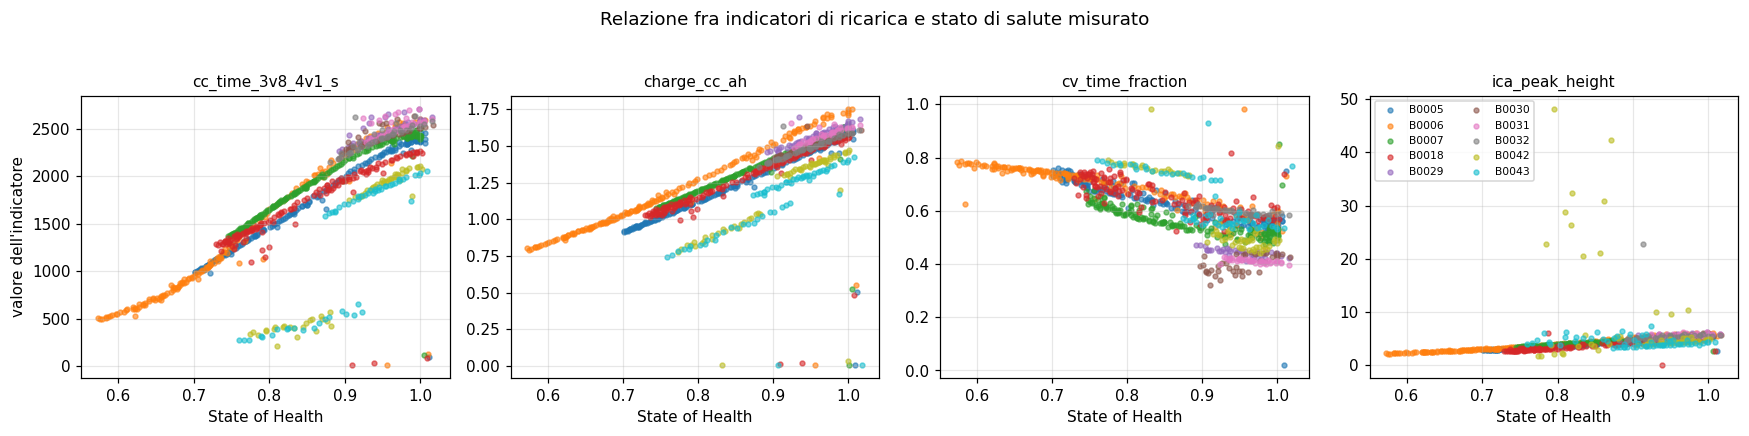

In [18]:
principali = ["cc_time_3v8_4v1_s", "charge_cc_ah", "cv_time_fraction", "ica_peak_height"]

fig, axes = plt.subplots(1, len(principali), figsize=(4 * len(principali), 3.8))
for ax, indicatore in zip(np.atleast_1d(axes), principali):
    for battery_id, gruppo in df_cycles[df_cycles.is_valid].groupby("battery_id"):
        valido = gruppo[[indicatore, "soh"]].dropna()
        ax.scatter(valido["soh"], valido[indicatore], s=10, alpha=0.6, label=battery_id)
    ax.set_xlabel("State of Health")
    ax.set_title(indicatore, fontsize=10)

np.atleast_1d(axes)[0].set_ylabel("valore dell'indicatore")
np.atleast_1d(axes)[-1].legend(fontsize=7, ncol=2)
fig.suptitle("Relazione fra indicatori di ricarica e stato di salute misurato", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01b_indicatori_vs_soh.png", dpi=200, bbox_inches="tight")
plt.show()


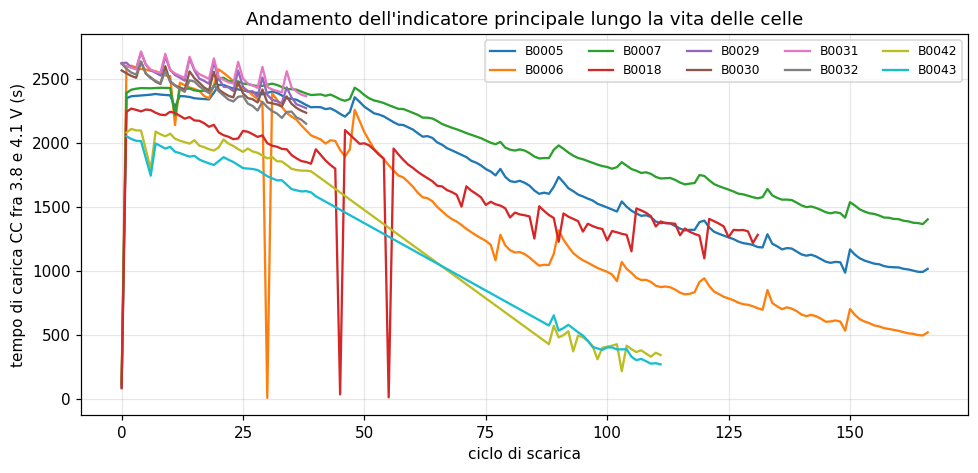

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.4))
for battery_id, gruppo in df_cycles[df_cycles.is_valid].groupby("battery_id"):
    valido = gruppo.dropna(subset=["cc_time_3v8_4v1_s"]).sort_values("discharge_cycle")
    ax.plot(valido.discharge_cycle, valido.cc_time_3v8_4v1_s, lw=1.5, label=battery_id)

ax.set_xlabel("ciclo di scarica")
ax.set_ylabel("tempo di carica CC fra 3.8 e 4.1 V (s)")
ax.set_title("Andamento dell'indicatore principale lungo la vita delle celle")
ax.legend(ncol=5, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01b_cc_time_per_ciclo.png", dpi=200, bbox_inches="tight")
plt.show()


## 12. Condizioni sperimentali per blocco di protocollo

Temperatura ambiente, corrente di scarica e tensione di cutoff sono costanti dentro
ciascun blocco e variano solo fra blocchi: la loro unità di analisi è il blocco di
protocollo, non il singolo ciclo.

Se più fattori variano insieme fra i gruppi risultano confusi tra loro, e con poche unità
sperimentali i rispettivi effetti non sono separabili. La tabella serve a rendere
esplicita questa condizione prima di qualunque analisi: va letta guardando quali colonne
cambiano *insieme*, perché è lì che si perde la possibilità di attribuire un effetto a
una causa sola.


In [20]:
protocolli = []
for blocco, gruppo in df_cycles.groupby("protocol_block"):
    validi = gruppo[gruppo.is_valid].sort_values("discharge_cycle")
    protocolli.append({
        "protocol_block": blocco,
        "battery_id": gruppo.battery_id.iloc[0],
        "ambiente_c": float(gruppo.ambient_temperature.iloc[0]),
        "corrente_scarica_a": float(gruppo.current_mean.abs().median()),
        "cutoff_v": float(gruppo.voltage_min.median()),
        "durata_scarica_s": float(gruppo.discharge_time.median()),
        "n_cicli": len(gruppo),
        "n_validi": int(gruppo.is_valid.sum()),
        "soh_iniziale": float(validi.soh.head(N_CICLI_RIFERIMENTO).median()) if len(validi) else np.nan,
        "soh_finale": float(validi.soh.tail(1).iloc[0]) if len(validi) else np.nan,
    })

protocolli = pd.DataFrame(protocolli).sort_values("protocol_block").reset_index(drop=True)
display(protocolli.round(3))

for colonna in ["ambiente_c", "corrente_scarica_a", "cutoff_v"]:
    print(f"{colonna:22s} livelli distinti: {sorted(protocolli[colonna].round(2).unique())}")

# Temperatura e corrente cambiano insieme: nel dataset non esiste un blocco caldo a
# corrente bassa né uno freddo a corrente alta. I due fattori sono confusi, e nessuna
# analisi condotta su questi dati può separarne gli effetti.
incrocio = (protocolli.assign(corrente=protocolli.corrente_scarica_a.round(0))
            .pivot_table(index="ambiente_c", columns="corrente",
                         values="protocol_block", aggfunc="count", fill_value=0))
print("\nBlocchi per combinazione di temperatura e corrente:")
display(incrocio)


,protocol_block,battery_id,ambiente_c,corrente_scarica_a,cutoff_v,durata_scarica_s,n_cicli,n_validi,soh_iniziale,soh_finale
0,B0005_p1,B0005,24.0,1.817,2.660,3086.078,168,168,1.000,0.722
1,B0006_p1,B0006,24.0,1.751,2.429,3086.078,168,168,1.000,0.589
2,B0007_p1,B0007,24.0,1.904,2.102,3086.078,168,168,1.000,0.762
3,B0018_p1,B0018,24.0,1.818,2.415,3047.875,132,132,1.000,0.729
4,B0029_p1,B0029,43.0,3.921,1.899,1617.953,40,40,1.000,0.888
5,B0030_p1,B0030,43.0,3.770,2.095,1617.953,40,40,1.000,0.892
6,B0031_p1,B0031,43.0,3.921,2.405,1617.953,40,40,1.000,0.924
7,B0032_p1,B0032,43.0,3.892,2.644,1617.953,40,40,1.000,0.877
8,B0042_p1,B0042,22.0,1.998,2.095,3015.000,41,40,1.000,0.906
9,B0042_p2,B0042,4.0,3.873,2.168,1030.703,71,25,0.877,0.774


ambiente_c             livelli distinti: [np.float64(4.0), np.float64(22.0), np.float64(24.0), np.float64(43.0)]
corrente_scarica_a     livelli distinti: [np.float64(0.46), np.float64(1.75), np.float64(1.82), np.float64(1.89), np.float64(1.9), np.float64(2.0), np.float64(3.77), np.float64(3.87), np.float64(3.89), np.float64(3.92)]
cutoff_v               livelli distinti: [np.float64(1.9), np.float64(2.1), np.float64(2.17), np.float64(2.41), np.float64(2.43), np.float64(2.46), np.float64(2.64), np.float64(2.66)]

Blocchi per combinazione di temperatura e corrente:


corrente,0.0,2.0,4.0
ambiente_c,,,
4.0,1,0,1
22.0,0,2,0
24.0,0,4,0
43.0,0,0,4


## 13. Tasso di degrado per cella

Pendenza dello State of Health rispetto al numero di ciclo, stimata ai minimi quadrati
sui soli cicli validi. La regressione è preferita alla differenza fra primo e ultimo
valore, che con dati rumorosi dipenderebbe da due sole osservazioni.

Le celle sono osservate per un numero di cicli molto diverso e il degrado accelera a fine
vita: confrontare i gruppi su finestre di lunghezza disuguale sfavorisce quelli osservati
più a lungo. Il confronto su **finestra comune** — gli stessi primi cicli per tutte — è
quindi quello corretto; la finestra completa è riportata a titolo di confronto.


In [21]:
FINESTRA_COMUNE = 40


def tasso_di_degrado(df, n_finestra=None):
    """Perdita di SoH in punti percentuali ogni 100 cicli, per cella."""
    righe = []
    for blocco, gruppo in df[df.is_valid].groupby("protocol_block"):
        gruppo = gruppo.sort_values("discharge_cycle")
        if n_finestra is not None:
            gruppo = gruppo.head(n_finestra)
            if len(gruppo) < n_finestra:
                continue  # blocco troppo corto per la finestra comune
        if len(gruppo) < 10:
            continue

        pendenza = np.polyfit(gruppo.discharge_cycle, gruppo.soh, 1)[0]
        righe.append({
            "protocol_block": blocco,
            "battery_id": gruppo.battery_id.iloc[0],
            "ambiente_c": float(gruppo.ambient_temperature.iloc[0]),
            "corrente_a": round(float(gruppo.current_mean.abs().median()), 1),
            "n_cicli_usati": len(gruppo),
            "fade_pct_per_100": -pendenza * 100 * 100,
        })
    return (pd.DataFrame(righe)
            .sort_values(["ambiente_c", "protocol_block"]).reset_index(drop=True))


def riepilogo_per_gruppo(tassi):
    return (tassi.groupby("ambiente_c")
            .agg(n_blocchi=("protocol_block", "count"),
                 media=("fade_pct_per_100", "mean"),
                 sd=("fade_pct_per_100", "std"),
                 minimo=("fade_pct_per_100", "min"),
                 massimo=("fade_pct_per_100", "max"))
            .round(3).reset_index())


tassi_completa = tasso_di_degrado(df_cycles)
tassi_comune = tasso_di_degrado(df_cycles, n_finestra=FINESTRA_COMUNE)

print("Finestra completa (lunghezze disuguali):")
display(riepilogo_per_gruppo(tassi_completa))

print(f"\nFinestra comune, primi {FINESTRA_COMUNE} cicli:")
display(riepilogo_per_gruppo(tassi_comune))

display(tassi_comune.round(3))


Finestra completa (lunghezze disuguali):


,ambiente_c,n_blocchi,media,sd,minimo,massimo
0,4.0,2,56.360,18.997,42.928,69.793
1,22.0,2,27.132,7.652,21.722,32.543
2,24.0,4,21.265,3.220,17.385,25.265
3,43.0,4,25.532,5.324,17.559,28.606



Finestra comune, primi 40 cicli:


,ambiente_c,n_blocchi,media,sd,minimo,massimo
0,22.0,2,27.132,7.652,21.722,32.543
1,24.0,4,18.196,13.895,5.792,31.910
2,43.0,4,25.532,5.324,17.559,28.606


,protocol_block,battery_id,ambiente_c,corrente_a,n_cicli_usati,fade_pct_per_100
0,B0042_p1,B0042,22.0,2.0,40,21.722
1,B0043_p1,B0043,22.0,1.9,40,32.543
2,B0005_p1,B0005,24.0,1.9,40,5.792
3,B0006_p1,B0006,24.0,2.0,40,28.415
4,B0007_p1,B0007,24.0,2.0,40,6.668
5,B0018_p1,B0018,24.0,1.9,40,31.910
6,B0029_p1,B0029,43.0,3.9,40,28.062
7,B0030_p1,B0030,43.0,3.8,40,27.900
8,B0031_p1,B0031,43.0,3.9,40,17.559
9,B0032_p1,B0032,43.0,3.9,40,28.606


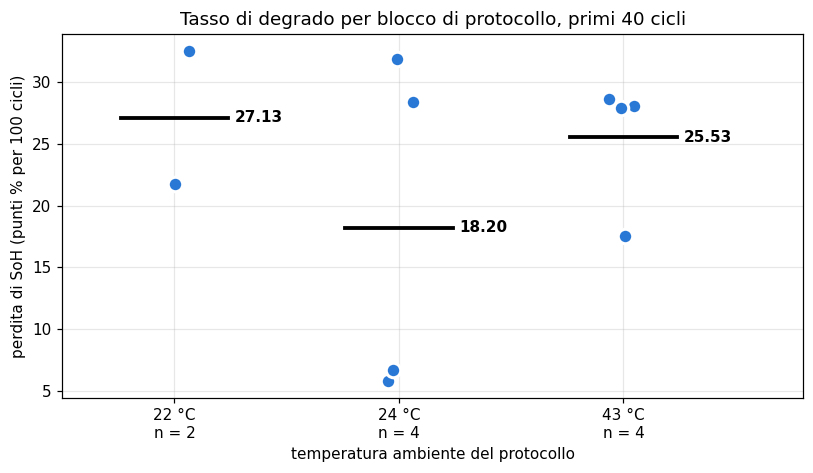

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
rng = np.random.default_rng(1)
gruppi = sorted(tassi_comune.ambiente_c.unique())

for i, temperatura in enumerate(gruppi):
    sotto = tassi_comune[tassi_comune.ambiente_c == temperatura]
    # Un punto per blocco: l'ampiezza campionaria resta visibile a chi legge.
    ax.scatter(i + rng.uniform(-0.07, 0.07, len(sotto)), sotto.fade_pct_per_100,
               s=90, color="#2a78d6", edgecolor="white", linewidth=2, zorder=3)
    media = sotto.fade_pct_per_100.mean()
    ax.plot([i - 0.24, i + 0.24], [media, media], color="black", lw=2.5, zorder=4)
    ax.annotate(f"{media:.2f}", (i + 0.27, media), fontweight="bold", va="center")

ax.set_xticks(range(len(gruppi)))
ax.set_xticklabels([f"{t:.0f} °C\nn = {(tassi_comune.ambiente_c == t).sum()}"
                    for t in gruppi])
ax.set_xlim(-0.5, len(gruppi) - 0.2)
ax.set_xlabel("temperatura ambiente del protocollo")
ax.set_ylabel("perdita di SoH (punti % per 100 cicli)")
ax.set_title(f"Tasso di degrado per blocco di protocollo, primi {FINESTRA_COMUNE} cicli")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_fade_rate_per_temperatura.png", dpi=200, bbox_inches="tight")
plt.show()


## 14. Curve di capacità e State of Health


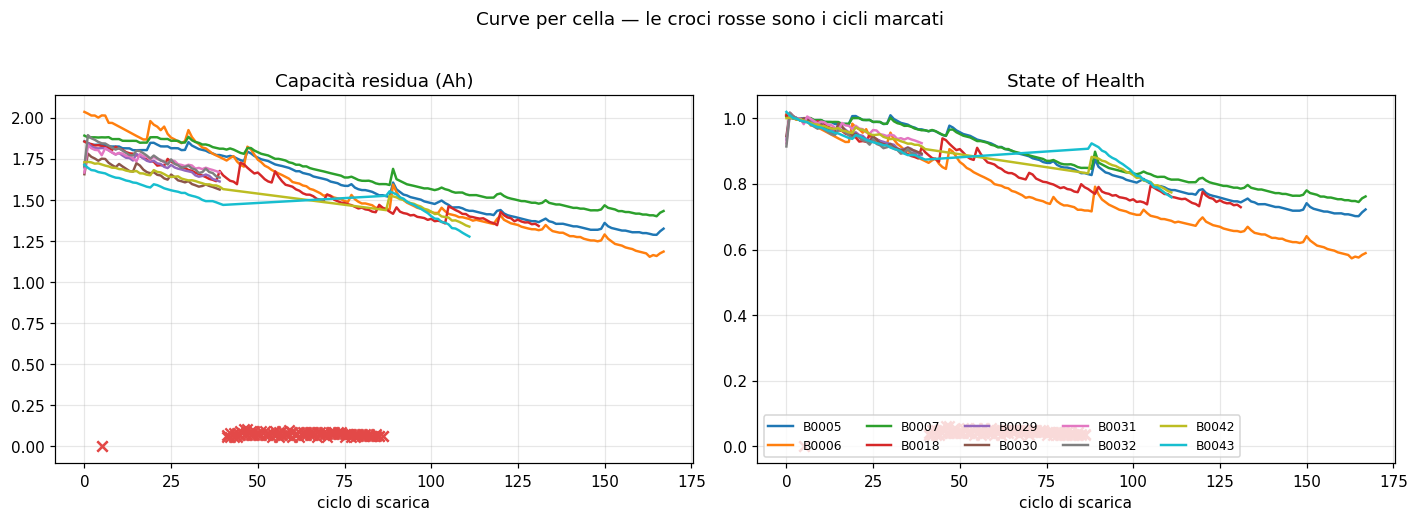

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for ax, colonna, titolo in [(axes[0], "capacity", "Capacità residua (Ah)"),
                            (axes[1], "soh", "State of Health")]:
    for battery_id, gruppo in df_cycles.groupby("battery_id"):
        validi = gruppo[gruppo.is_valid]
        ax.plot(validi.discharge_cycle, validi[colonna], lw=1.6, label=battery_id)
        # I cicli marcati restano visibili: nasconderli renderebbe la selezione
        # non verificabile da chi legge.
        marcati = gruppo[gruppo.is_anomalous]
        ax.scatter(marcati.discharge_cycle, marcati[colonna],
                   marker="x", s=45, color="#e34948", zorder=5)
    ax.set_xlabel("ciclo di scarica")
    ax.set_title(titolo)

axes[1].legend(ncol=5, fontsize=8, loc="lower left")
fig.suptitle("Curve per cella — le croci rosse sono i cicli marcati", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_curve_capacita_soh.png", dpi=200, bbox_inches="tight")
plt.show()


In [24]:
print("Statistiche descrittive sui cicli validi:")
display(df_cycles[df_cycles.is_valid][[
    "capacity", "soh", "voltage_mean", "voltage_min",
    "temperature_mean", "temperature_max", "discharge_time",
]].describe().round(3))

display(df_cycles[df_cycles.is_valid]
        .groupby("battery_id")["soh"].agg(["min", "max", "mean"]).round(4))


Statistiche descrittive sui cicli validi:


,capacity,soh,voltage_mean,voltage_min,temperature_mean,temperature_max,discharge_time
count,926.000,926.000,926.000,926.000,926.000,926.000,926.000
mean,1.600,0.866,3.475,2.351,34.537,41.614,2971.864
std,0.182,0.106,0.061,0.234,10.372,11.079,829.433
min,1.154,0.573,3.314,1.737,7.677,10.465,1536.781
25%,1.449,0.780,3.420,2.152,31.200,37.903,2832.949
50%,1.614,0.889,3.484,2.405,32.422,39.952,3016.289
75%,1.748,0.957,3.521,2.491,33.580,41.240,3283.563
max,2.035,1.019,3.574,2.700,54.917,63.024,5703.296


,min,max,mean
battery_id,,,
B0005,0.7015,1.0115,0.8568
B0006,0.5731,1.0109,0.7683
B0007,0.7447,1.0055,0.8744
B0018,0.7290,1.0084,0.8468
B0029,0.8878,1.0159,0.9506
B0030,0.8921,1.0170,0.9482
B0031,0.9237,1.0157,0.9661
B0032,0.8769,1.0153,0.9405
B0042,0.7739,1.0019,0.9086


## 15. Descrittori riferiti all'inizio vita della cella

Lo State of Health non è la capacità in ampere-ora: è la capacità **rapportata a quella
iniziale della stessa cella**. La ragione è che due celle nuove non hanno la stessa
capacità di fabbrica, e confrontare valori assoluti significherebbe confondere la
dispersione di produzione con l'invecchiamento.

Lo stesso ragionamento vale per tutti gli altri descrittori, e non era stato applicato.
Tensione minima, durata della scarica e riscaldamento hanno un valore di partenza che
dipende dalla cella e dal protocollo: al variare di questi la loro scala cambia, e un
modello addestrato su alcune celle riceve da una cella nuova valori collocati fuori
dall'intervallo che ha visto.

L'entità del problema si misura in deviazioni standard. Normalizzando con media e
deviazione standard delle sole celle di addestramento, `temperature_mean` sulle celle a
43 °C arriva a **26 deviazioni standard**: non è un valore raro, è un valore che la rete
non ha mai visto neppure lontanamente, e la sua uscita perde senso.

Si applicano quindi due trasformazioni, entrambe con la stessa logica del SoH.

**Le grandezze termiche diventano riscaldamenti.** `temperature_mean` e
`temperature_max` sono in larga parte determinate dalla temperatura ambiente imposta
dallo sperimentatore. Sottraendola si ottiene il riscaldamento della cella rispetto
all'ambiente, che è invece una proprietà della cella: cresce con la resistenza interna e
quindi con il degrado.

**Ogni descrittore viene diviso per il proprio valore di inizio blocco**, la mediana dei
primi cicli, come già si fa per la capacità. Il descrittore risultante vale circa 1
all'inizio della vita e misura di quanto la grandezza è derivata da allora.

Il riferimento usa soltanto i primi cicli della stessa cella nello stesso protocollo:
informazione disponibile su una cella in servizio, che non guarda né al futuro né alle
altre celle. Non introduce quindi alcuna anticipazione.


In [25]:
# Riscaldamento rispetto all'ambiente: proprietà della cella, non del banco di prova.
df_cycles["temperature_mean_rise"] = (
    df_cycles["temperature_mean"] - df_cycles["ambient_temperature"])
df_cycles["temperature_max_rise"] = (
    df_cycles["temperature_max"] - df_cycles["ambient_temperature"])

DESCRITTORI_DA_RIFERIRE = [
    "voltage_mean", "voltage_min", "voltage_max", "voltage_std",
    "temperature_mean_rise", "temperature_max_rise", "temperature_std",
    "discharge_time", "num_measurements",
]


def riferisci_a_inizio_vita(df, colonne, n_riferimento=N_CICLI_RIFERIMENTO):
    """Aggiunge `<colonna>_rel`: il valore diviso per la mediana dei primi cicli
    validi dello stesso blocco di protocollo."""
    df = df.copy()
    for colonna in colonne:
        riferimento = (df[df.is_valid].groupby("protocol_block")[colonna]
                       .apply(lambda s: s.iloc[:n_riferimento].median()))
        base = df["protocol_block"].map(riferimento)
        # Un riferimento nullo renderebbe il rapporto indefinito: in quel caso si
        # ricade sul valore assoluto, segnalandolo.
        degenere = base.abs() < 1e-9
        if degenere.any():
            print(f"attenzione: riferimento nullo per {colonna} su "
                  f"{sorted(df.loc[degenere, 'protocol_block'].unique())}")
            base = base.mask(degenere, 1.0)
        df[colonna + "_rel"] = df[colonna] / base
    return df


# Gli indicatori di ricarica ricevono lo stesso trattamento. Il protocollo di carica è
# nominalmente identico su tutte le celle — stessa corrente, stessi limiti di tensione —
# ma si svolge alla temperatura ambiente della cella, e al freddo la resistenza interna
# più alta accorcia la fase a corrente costante e allunga la coda a tensione costante.
# Il riferimento a inizio vita toglie quello scostamento e lascia il solo invecchiamento.
INDICATORI_DA_RIFERIRE = [c for c in INDICATORI if c in df_cycles.columns
                          and c != "charge_temp_max"]

df_cycles = riferisci_a_inizio_vita(
    df_cycles, DESCRITTORI_DA_RIFERIRE + INDICATORI_DA_RIFERIRE)
RELATIVI = [c + "_rel" for c in DESCRITTORI_DA_RIFERIRE]

display(df_cycles[df_cycles.is_valid][RELATIVI].describe().round(3))


attenzione: riferimento nullo per charge_temp_rise su ['B0005_p1', 'B0007_p1', 'B0029_p1', 'B0030_p1', 'B0031_p1', 'B0032_p1', 'B0042_p1', 'B0042_p2', 'B0043_p1', 'B0043_p2']


,voltage_mean_rel,voltage_min_rel,voltage_max_rel,voltage_std_rel,temperature_mean_rise_rel,temperature_max_rise_rel,temperature_std_rel,discharge_time_rel,num_measurements_rel
count,926.000,926.000,926.000,926.000,926.000,926.000,926.000,926.000,926.000
mean,0.991,1.006,1.000,1.008,1.006,1.032,1.098,0.891,1.218
std,0.014,0.033,0.002,0.060,0.092,0.072,0.110,0.071,0.414
min,0.955,0.858,0.976,0.821,0.785,0.865,0.866,0.765,0.559
25%,0.982,0.989,1.000,0.973,0.945,0.985,1.006,0.827,0.865
50%,0.995,1.007,1.000,1.004,0.999,1.023,1.072,0.907,0.989
75%,1.001,1.027,1.001,1.051,1.063,1.088,1.177,0.949,1.626
max,1.011,1.086,1.011,1.167,1.288,1.201,1.352,1.036,1.903


### Quanto guadagna la trasferibilità

Il confronto si fa così: si normalizzano i descrittori con media e deviazione standard
delle sole celle di addestramento, e si guarda a quante deviazioni standard finiscono i
valori delle altre celle. Un descrittore che resta entro poche deviazioni standard è
confrontabile fra protocolli; uno che ne raggiunge decine non lo è, e in addestramento la
rete non ha visto nulla di simile.


In [26]:
CELLE_ADDESTRAMENTO = ["B0005", "B0006"]

addestramento = df_cycles[df_cycles.battery_id.isin(CELLE_ADDESTRAMENTO) & df_cycles.is_valid]
altri = df_cycles[~df_cycles.battery_id.isin(CELLE_ADDESTRAMENTO) & df_cycles.is_valid]

confronto = []
for grezza in DESCRITTORI_DA_RIFERIRE:
    for colonna, etichetta in [(grezza, "assoluto"), (grezza + "_rel", "relativo")]:
        media, sd = addestramento[colonna].mean(), addestramento[colonna].std()
        z = np.abs((altri[colonna] - media) / sd) if sd > 1e-12 else np.full(len(altri), np.inf)
        confronto.append({"descrittore": grezza, "forma": etichetta,
                          "z_massimo_altre_celle": float(np.max(z))})

confronto = (pd.DataFrame(confronto)
             .pivot(index="descrittore", columns="forma", values="z_massimo_altre_celle")
             .round(1))
confronto["riduzione"] = (confronto["assoluto"] / confronto["relativo"]).round(1)
display(confronto.sort_values("assoluto", ascending=False))

print("Valore massimo, su tutti i descrittori:")
print(f"  in forma assoluta: {confronto['assoluto'].max():.1f} deviazioni standard")
print(f"  in forma relativa: {confronto['relativo'].max():.1f} deviazioni standard")


forma,assoluto,relativo,riduzione
descrittore,,,
voltage_max,11.6,18.9,0.6
voltage_std,11.1,3.7,3.0
discharge_time,10.5,2.7,3.9
temperature_max_rise,7.4,2.2,3.4
temperature_std,6.8,2.4,2.8
voltage_min,6.1,5.2,1.2
temperature_mean_rise,6.0,2.5,2.4
voltage_mean,3.2,1.7,1.9
num_measurements,2.9,3.4,0.9


Valore massimo, su tutti i descrittori:
  in forma assoluta: 11.6 deviazioni standard
  in forma relativa: 18.9 deviazioni standard


## 16. Celle aggiuntive per gli esperimenti supplementari

Il dataset NASA contiene altre celle oltre alle dieci del progetto. Non entrano
nell'analisi principale, ma servono all'esperimento sulla quantità di dati di
addestramento: per stabilire se aggiungere celle migliori le prestazioni occorre
disporne.

Vengono elaborate con le stesse funzioni definite sopra e salvate in un file separato,
così che il dataset principale resti quello dichiarato nella proposta. La tabella dei
protocolli si estende anche a queste celle, perché è da lì che si ricava quali
condividano le condizioni sperimentali del gruppo di riferimento.


In [27]:
if mat_aggiuntive:
    righe_extra = []
    for percorso in mat_aggiuntive:
        righe, _ = extract_discharge_cycles(percorso)
        righe_extra.extend(righe)

    df_extra = (pd.DataFrame(righe_extra)
                .sort_values(["battery_id", "discharge_cycle"]).reset_index(drop=True))

    df_extra["capacity_reference"] = (
        df_extra.groupby("battery_id")["capacity"]
        .transform(lambda s: s.iloc[:N_CICLI_RIFERIMENTO].median())
    )
    df_extra["soh"] = df_extra["capacity"] / df_extra["capacity_reference"]

    df_extra["capacity_local_median"] = (
        df_extra.groupby("battery_id")["capacity"]
        .transform(lambda s: s.rolling(FINESTRA_LOCALE, center=True, min_periods=3).median())
    )
    df_extra["is_anomalous"] = (
        (df_extra["capacity"] < RAPPORTO_CROLLO * df_extra["capacity_local_median"])
        | (df_extra["soh"] < SOGLIA_ASSOLUTA)
    )
    df_extra["is_valid"] = ~df_extra["is_anomalous"]
    df_extra = assegna_segmenti(assegna_blocchi_protocollo(df_extra))
    df_extra["temperature_mean_rise"] = (
        df_extra["temperature_mean"] - df_extra["ambient_temperature"])
    df_extra["temperature_max_rise"] = (
        df_extra["temperature_max"] - df_extra["ambient_temperature"])
    df_extra = riferisci_a_inizio_vita(
        df_extra, DESCRITTORI_DA_RIFERIRE
        + [c for c in INDICATORI_DA_RIFERIRE if c in df_extra.columns])

    print(f"Celle aggiuntive: {df_extra.battery_id.nunique()}   "
          f"cicli: {len(df_extra)}   validi: {int(df_extra.is_valid.sum())}")
    display(df_extra.groupby("battery_id").size().rename("n_cicli").to_frame().T)
else:
    df_extra = pd.DataFrame()
    print("Nessuna cella aggiuntiva disponibile negli archivi estratti.")
    print("L'esperimento supplementare sulla quantità di dati non potrà essere eseguito.")
    print(f"Verifica che {BATTERY_ROOT.name} contenga i due archivi per anno e "
          "rilancia la cella di raccolta.")


Celle aggiuntive: 12   cicli: 1023   validi: 965


battery_id,B0025,B0026,B0027,B0028,B0033,B0034,B0036,B0038,B0039,B0040,B0041,B0044
n_cicli,28,28,28,28,197,197,197,47,47,47,67,112


In [28]:
protocolli["nel_progetto"] = True

if len(df_extra):
    righe_protocollo = []
    for blocco, gruppo in df_extra[df_extra.is_valid].groupby("protocol_block"):
        validi = gruppo.sort_values("discharge_cycle")
        righe_protocollo.append({
            "protocol_block": blocco,
            "battery_id": gruppo.battery_id.iloc[0],
            "ambiente_c": float(gruppo.ambient_temperature.iloc[0]),
            "corrente_scarica_a": float(gruppo.current_mean.abs().median()),
            "cutoff_v": float(gruppo.voltage_min.median()),
            "durata_scarica_s": float(gruppo.discharge_time.median()),
            "n_cicli": len(gruppo),
            "n_validi": int(gruppo.is_valid.sum()),
            "soh_iniziale": float(validi.soh.head(N_CICLI_RIFERIMENTO).median()),
            "soh_finale": float(validi.soh.tail(1).iloc[0]),
            "nel_progetto": False,
        })
    protocolli_completi = pd.concat(
        [protocolli, pd.DataFrame(righe_protocollo)], ignore_index=True)
else:
    protocolli_completi = protocolli.copy()

# Il protocollo di riferimento è quello delle celle su cui il modello viene
# addestrato nell'analisi principale.
riferimento = protocolli[protocolli.battery_id.isin(CELLE_ADDESTRAMENTO)]
corrente_rif = float(riferimento.corrente_scarica_a.median())
ambiente_rif = float(riferimento.ambiente_c.median())

protocolli_completi["stesso_protocollo"] = (
    ((protocolli_completi.corrente_scarica_a - corrente_rif).abs() < 0.5)
    & ((protocolli_completi.ambiente_c - ambiente_rif).abs() < 5.0)
)

display(protocolli_completi.round(3))

print(f"Protocollo di riferimento: {corrente_rif:.1f} A, {ambiente_rif:.0f} °C")
print("Stesso protocollo: ",
      ", ".join(protocolli_completi[protocolli_completi.stesso_protocollo].protocol_block))
print("Protocollo diverso:",
      ", ".join(protocolli_completi[~protocolli_completi.stesso_protocollo].protocol_block))


,protocol_block,battery_id,ambiente_c,corrente_scarica_a,cutoff_v,durata_scarica_s,n_cicli,n_validi,soh_iniziale,soh_finale,nel_progetto,stesso_protocollo
0,B0005_p1,B0005,24.0,1.817,2.660,3086.078,168,168,1.000,0.722,True,True
1,B0006_p1,B0006,24.0,1.751,2.429,3086.078,168,168,1.000,0.589,True,True
2,B0007_p1,B0007,24.0,1.904,2.102,3086.078,168,168,1.000,0.762,True,True
3,B0018_p1,B0018,24.0,1.818,2.415,3047.875,132,132,1.000,0.729,True,True
4,B0029_p1,B0029,43.0,3.921,1.899,1617.953,40,40,1.000,0.888,True,False
5,B0030_p1,B0030,43.0,3.770,2.095,1617.953,40,40,1.000,0.892,True,False
6,B0031_p1,B0031,43.0,3.921,2.405,1617.953,40,40,1.000,0.924,True,False
7,B0032_p1,B0032,43.0,3.892,2.644,1617.953,40,40,1.000,0.877,True,False
8,B0042_p1,B0042,22.0,1.998,2.095,3015.000,41,40,1.000,0.906,True,True
9,B0042_p2,B0042,4.0,3.873,2.168,1030.703,71,25,0.877,0.774,True,False


Protocollo di riferimento: 1.8 A, 24 °C
Stesso protocollo:  B0005_p1, B0006_p1, B0007_p1, B0018_p1, B0042_p1, B0043_p1, B0033_p1, B0034_p1, B0036_p1, B0039_p1, B0040_p1, B0044_p1
Protocollo diverso: B0029_p1, B0030_p1, B0031_p1, B0032_p1, B0042_p2, B0043_p2, B0025_p1, B0026_p1, B0027_p1, B0028_p1, B0038_p1, B0038_p2, B0039_p2, B0040_p2, B0041_p1, B0044_p2


## 17. Salvataggio

`battery_cycles.csv` contiene tutti i cicli estratti con le colonne aggiunte qui:
`is_valid`, `protocol_block`, `segment_id` e i descrittori riferiti all'inizio vita. La
selezione dei cicli utilizzabili avviene a valle, dove la contiguità può essere
verificata.


In [29]:
percorso_cicli = DATA_PROCESSED / "battery_cycles.csv"
df_cycles.to_csv(percorso_cicli, index=False)

protocolli.to_csv(TABLES_DIR / "protocolli_batterie.csv", index=False)
tassi_comune.to_csv(TABLES_DIR / "fade_rate_per_batteria.csv", index=False)
riepilogo_segmenti.to_csv(TABLES_DIR / "segmenti_contigui.csv", index=False)
correlazioni.to_csv(TABLES_DIR / "indicatori_carica_correlazioni.csv", index=False)
protocolli_completi.to_csv(TABLES_DIR / "protocolli_tutte_le_celle.csv", index=False)

if len(df_extra):
    df_extra.to_csv(DATA_PROCESSED / "battery_cycles_extra.csv", index=False)
    print("Celle aggiuntive salvate in data/processed/battery_cycles_extra.csv")

print("File salvati:")
for percorso in [percorso_cicli,
                 TABLES_DIR / "protocolli_batterie.csv",
                 TABLES_DIR / "fade_rate_per_batteria.csv",
                 TABLES_DIR / "segmenti_contigui.csv",
                 TABLES_DIR / "indicatori_carica_correlazioni.csv"]:
    print("  ", percorso.relative_to(PROJECT_ROOT))

print(f"\n{len(df_cycles)} cicli totali, "
      f"{int(df_cycles.is_valid.sum())} validi, "
      f"{int((df_cycles.segment_id >= 0).sum())} assegnati a un tratto")
print(f"{len(INDICATORI)} indicatori di ricarica, "
      f"{len(coerenti)} con segno coerente fra le celle")
print("\nNotebook successivo: 02_sequence_preparation.ipynb")


Celle aggiuntive salvate in data/processed/battery_cycles_extra.csv
File salvati:
   data/processed/battery_cycles.csv
   results/tables/protocolli_batterie.csv
   results/tables/fade_rate_per_batteria.csv
   results/tables/segmenti_contigui.csv
   results/tables/indicatori_carica_correlazioni.csv

1020 cicli totali, 926 validi, 926 assegnati a un tratto
11 indicatori di ricarica, 5 con segno coerente fra le celle

Notebook successivo: 02_sequence_preparation.ipynb
